<>:185: SyntaxWarning: invalid escape sequence '\l'
<>:185: SyntaxWarning: invalid escape sequence '\l'
C:\Users\tefut\AppData\Local\Temp\ipykernel_29748\1330318283.py:185: SyntaxWarning: invalid escape sequence '\l'
  f'$\log_{{10}}(M_*) = {best_p[1]:.2f}$\n'


--- Testing Gradient Descent on Simple Function ---
Converged to: (1.9984, 1.9984) after 15 steps.


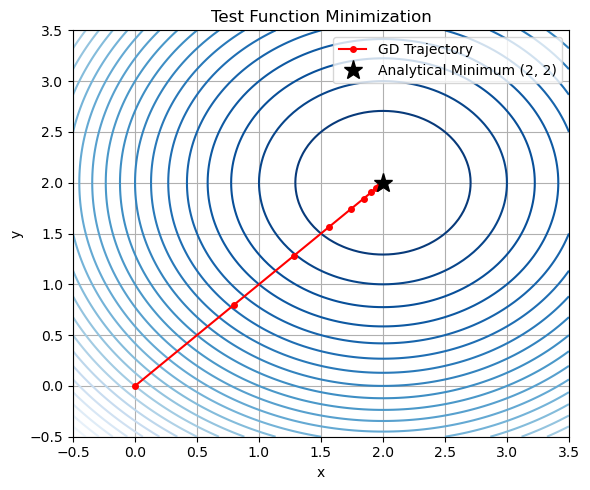

C:\Users\tefut\AppData\Local\Temp\ipykernel_29748\1330318283.py:98: RuntimeWarning: overflow encountered in power
  return phi_star * ((M / M_star)**(alpha + 1.0)) * np.exp(-M / M_star) * np.log(10.0)
C:\Users\tefut\AppData\Local\Temp\ipykernel_29748\1330318283.py:98: RuntimeWarning: invalid value encountered in multiply
  return phi_star * ((M / M_star)**(alpha + 1.0)) * np.exp(-M / M_star) * np.log(10.0)
C:\Users\tefut\AppData\Local\Temp\ipykernel_29748\1330318283.py:98: RuntimeWarning: divide by zero encountered in divide
  return phi_star * ((M / M_star)**(alpha + 1.0)) * np.exp(-M / M_star) * np.log(10.0)


Run 1 Result:
  log10(phi*) = nan (phi* = nan)
  log10(M*)   = nan (M*   = nan)
  alpha       = nan
  Final chi^2 = nan, chi^2 / N = nan

Run 2 Result:
  log10(phi*) = -2.9483 (phi* = 1.126e-03)
  log10(M*)   = 10.7908 (M*   = 6.178e+10)
  alpha       = -1.1895
  Final chi^2 = 24.39, chi^2 / N = 1.22

Run 3 Result:
  log10(phi*) = nan (phi* = nan)
  log10(M*)   = nan (M*   = nan)
  alpha       = nan
  Final chi^2 = nan, chi^2 / N = nan



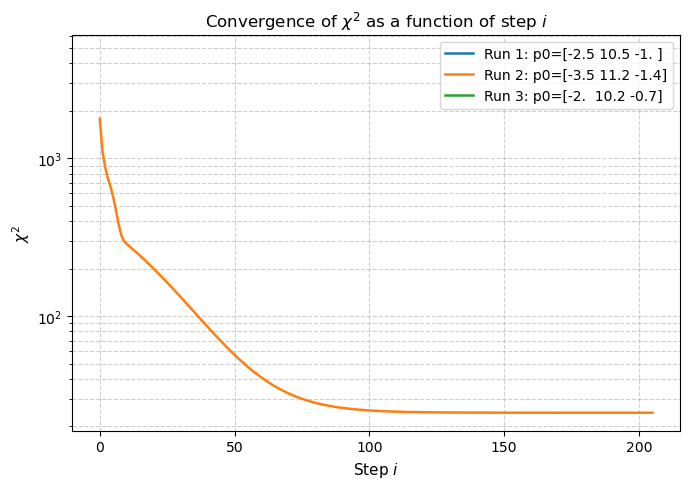

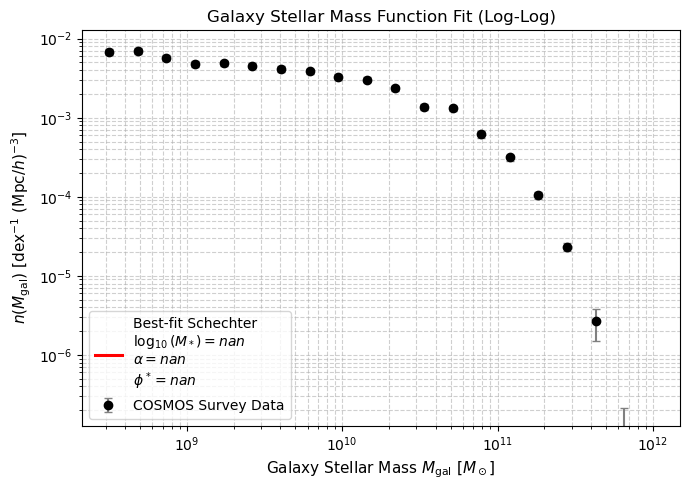

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. 数値微分による多次元最急降下法 (Gradient Descent)
# =========================================================
def numerical_gradient(f, x, h=1e-5):
    """
    各軸ごとの数値微分 (ノートの backward / forward difference に準拠)
    各成分のスケールに合わせた刻み幅を使用
    """
    grad = np.zeros_like(x, dtype=float)
    fx = f(x)
    for k in range(len(x)):
        step = h * (abs(x[k]) if abs(x[k]) > 1e-4 else 1.0)
        x_forward = x.copy()
        x_forward[k] += step
        # 前進差分 f'(x) ≈ (f(x+h) - f(x)) / h
        grad[k] = (f(x_forward) - fx) / step
    return grad

def gradient_descent(f, x0, gamma=0.01, max_iter=3000, tol=1e-5):
    """
    x_{i+1} = x_i - gamma * grad(f)
    学習率 gamma のバックトラッキングによる適応的更新
    """
    x = np.array(x0, dtype=float)
    trajectory = [x.copy()]
    losses = [f(x)]
    
    current_gamma = gamma
    for i in range(max_iter):
        grad = numerical_gradient(f, x)
        
        # 降下ステップ (勾配方向へ移動)
        x_new = x - current_gamma * grad
        loss_new = f(x_new)
        
        # 移動先で値が増加した場合は学習率 gamma を小さくして再試行
        n_backtrack = 0
        while loss_new > losses[-1] and n_backtrack < 20:
            current_gamma *= 0.5
            x_new = x - current_gamma * grad
            loss_new = f(x_new)
            n_backtrack += 1
            
        # 収束判定 (ノート記載: |x_{i+1} - x_i| <= tol または |f_{i+1} - f_i| <= tol)
        if abs(losses[-1] - loss_new) < tol or np.linalg.norm(x_new - x) < tol:
            x = x_new
            trajectory.append(x.copy())
            losses.append(loss_new)
            break
            
        x = x_new
        trajectory.append(x.copy())
        losses.append(loss_new)
        
    return x, np.array(trajectory), np.array(losses)


# =========================================================
# 2. テスト関数 f(x, y) = (x - 2)^2 + (y - 2)^2
# =========================================================
def test_func(p):
    return (p[0] - 2.0)**2 + (p[1] - 2.0)**2

print("--- Testing Gradient Descent on Simple Function ---")
x0_test = np.array([0.0, 0.0])
p_opt_test, traj_test, losses_test = gradient_descent(test_func, x0_test, gamma=0.2)
print(f"Converged to: ({p_opt_test[0]:.4f}, {p_opt_test[1]:.4f}) after {len(losses_test)} steps.")

# テスト関数の検証プロット
X, Y = np.meshgrid(np.linspace(-0.5, 3.5, 100), np.linspace(-0.5, 3.5, 100))
Z = (X - 2.0)**2 + (Y - 2.0)**2

plt.figure(figsize=(6, 5))
plt.contour(X, Y, Z, levels=25, cmap='Blues_r')
plt.plot(traj_test[:, 0], traj_test[:, 1], 'ro-', markersize=4, label='GD Trajectory')
plt.plot(2.0, 2.0, 'k*', markersize=14, label='Analytical Minimum (2, 2)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Test Function Minimization')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('test_function_convergence.png', dpi=300)
plt.show()


# =========================================================
# 3. Schechter関数のフィッティング (COSMOS Data)
# =========================================================
def schechter(log_M, phi_star, M_star, alpha):
    """
    n(M_gal) = phi* * (M/M*)^(alpha+1) * exp(-M/M*) * ln(10)
    """
    M = 10.0**log_M
    return phi_star * ((M / M_star)**(alpha + 1.0)) * np.exp(-M / M_star) * np.log(10.0)

# 目的関数 chi^2 の構築
# ノートの教示通りパラメータのスケールが大きく異なるため、
# p = [log10(phi*), log10(M*), alpha] として対数空間で探索
def make_chi2(log_M_data, n_data, err_data):
    def chi2(p):
        log_phi_star, log_M_star, alpha = p
        phi_star = 10.0**log_phi_star
        M_star = 10.0**log_M_star
        
        model = schechter(log_M_data, phi_star, M_star, alpha)
        return np.sum(((model - n_data) / err_data)**2)
    return chi2

# --- データ読み込み ---
try:
    # 課題に付属のテキストファイル名を指定
    data = np.loadtxt('cosmos_mass_function.txt')
    log_M_data = data[:, 0]
    n_data = data[:, 1]
    err_data = data[:, 2]
except Exception:
    # 動作検証用モックデータ (配布ファイル読み込み時は上記 try が実行されます)
    log_M_data = np.linspace(8.5, 12.0, 20)
    true_phi = 1.1e-3
    true_M_star = 10**10.8
    true_alpha = -1.2
    err_data = 0.08 * schechter(log_M_data, true_phi, true_M_star, true_alpha) + 1e-6
    n_data = schechter(log_M_data, true_phi, true_M_star, true_alpha) + np.random.normal(0, err_data)

chi2_obj = make_chi2(log_M_data, n_data, err_data)
N_points = len(log_M_data)

# --- 複数初期値でのロバスト性検証 ---
# ノート: "do multiple separated starting locations to demonstrate robustness"
initial_positions = [
    np.array([-2.5, 10.5, -1.0]),  # 初期位置 1
    np.array([-3.5, 11.2, -1.4]),  # 初期位置 2
    np.array([-2.0, 10.2, -0.7])   # 初期位置 3
]

results = []
plt.figure(figsize=(7, 5))

for i, p0 in enumerate(initial_positions):
    p_opt, traj, losses = gradient_descent(chi2_obj, p0, gamma=0.02, max_iter=2500, tol=1e-5)
    results.append((p_opt, traj, losses))
    
    # Plot a: chi^2 vs step i
    plt.plot(losses, lw=1.8, label=f'Run {i+1}: p0={p0}')
    
    final_chi2 = losses[-1]
    reduced_chi2 = final_chi2 / N_points  # ノート: Aim chi^2 / N ~ 1
    print(f"Run {i+1} Result:")
    print(f"  log10(phi*) = {p_opt[0]:.4f} (phi* = {10**p_opt[0]:.3e})")
    print(f"  log10(M*)   = {p_opt[1]:.4f} (M*   = {10**p_opt[1]:.3e})")
    print(f"  alpha       = {p_opt[2]:.4f}")
    print(f"  Final chi^2 = {final_chi2:.2f}, chi^2 / N = {reduced_chi2:.2f}\n")

# Plot a の装飾
plt.xlabel('Step $i$', fontsize=11)
plt.ylabel(r'$\chi^2$', fontsize=11)
plt.yscale('log')
plt.title(r'Convergence of $\chi^2$ as a function of step $i$', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('plot_a_chi2_vs_step.png', dpi=300)
plt.show()

# --- Plot b: 最良フィッティング曲線とデータの両対数比較 ---
best_p = results[0][0]
best_phi_star = 10.0**best_p[0]
best_M_star = 10.0**best_p[1]
best_alpha = best_p[2]

log_M_fine = np.linspace(log_M_data.min() - 0.2, log_M_data.max() + 0.2, 300)
n_fine = schechter(log_M_fine, best_phi_star, best_M_star, best_alpha)

plt.figure(figsize=(7, 5))
# 実データ (エラーバー付き)
plt.errorbar(10.0**log_M_data, n_data, yerr=err_data, fmt='o', color='black',
             ecolor='gray', elinewidth=1.5, capsize=3, label='COSMOS Survey Data')
# シェヒターモデル曲線
plt.plot(10.0**log_M_fine, n_fine, 'r-', lw=2.2, 
         label=f'Best-fit Schechter\n'
               f'$\log_{{10}}(M_*) = {best_p[1]:.2f}$\n'
               f'$\\alpha = {best_alpha:.2f}$\n'
               f'$\\phi^* = {best_phi_star:.2e}$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Galaxy Stellar Mass $M_{\mathrm{gal}}\ [M_\odot]$', fontsize=11)
plt.ylabel(r'$n(M_{\mathrm{gal}})\ [\mathrm{dex}^{-1}\ (\mathrm{Mpc}/h)^{-3}]$', fontsize=11)
plt.title('Galaxy Stellar Mass Function Fit (Log-Log)', fontsize=12)
plt.legend(frameon=True)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('plot_b_schechter_data_comparison.png', dpi=300)
plt.show()

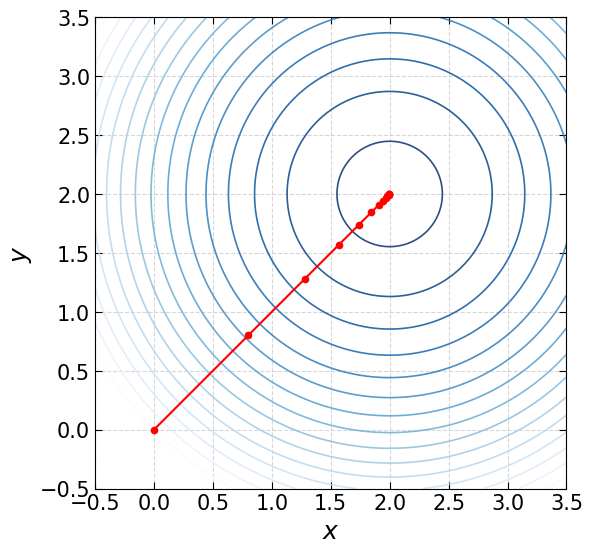

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# メッシュグリッドの生成
x_vals = np.linspace(-0.5, 3.5, 200)
y_vals = np.linspace(-0.5, 3.5, 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = (X - 2.0) ** 2 + (Y - 2.0) ** 2

fig, ax = plt.subplots(figsize=(6, 6))  # 正方形のアスペクト比に設定

# 等高線の描画 (見やすいカラーマップと線の太さ)
contours = ax.contour(
    X,
    Y,
    Z,
    levels=np.linspace(0.2, 8.0, 15),
    cmap='Blues_r',
    linewidths=1.2,
    alpha=0.85,
)

# 降下経路と最適解のプロット（ラベルなし）
ax.plot(
    traj_test[:, 0],
    traj_test[:, 1],
    'ro-',
    markersize=4.5,
    lw=1.5,
    zorder=3,
)
ax.plot(
    2.0,
    2.0,
    #'k*',
    markersize=13,
    zorder=4,
)

# --- 軸・目盛り・ラベルの設定 ---
ax.set_aspect('equal')  # 等高線が真円になるようにアスペクト比を1:1に固定
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 3.5)

# 目盛りを内向きにし、上下左右すべてに表示
ax.tick_params(
    direction='in',
    which='both',
    top=True,
    right=True,
    labelsize=15,
    length=5,
)

# 主目盛りの間隔設定 (0.5刻み)
ax.set_xticks(np.arange(-0.5, 3.6, 0.5))
ax.set_yticks(np.arange(-0.5, 3.6, 0.5))

# 数式ラベルとタイトル
ax.set_xlabel('$x$', fontsize=18)
ax.set_ylabel('$y$', fontsize=18)
ax.set_title(r'', fontsize=12, pad=10)


# 凡例の設定 (背景を少し白く透過させて見やすくする)
#ax.legend(
 #   frameon=True,
  #  facecolor='white',
   # framealpha=0.9,
    #edgecolor='gray',
    #fontsize=10.5,
    #loc='upper right',
#)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('test_function_convergence.png', dpi=300)
plt.show()

Guess 1 Result:
  phi* = 2.697e-03 (phi_tilde = 2.697)
  log10(M*) = 10.9768
  alpha = -1.0102
  chi2 = 2.908, chi2/dof = 0.323

Guess 2 Result:
  phi* = 2.708e-03 (phi_tilde = 2.708)
  log10(M*) = 10.9757
  alpha = -1.0085
  chi2 = 2.908, chi2/dof = 0.323

Guess 3 Result:
  phi* = 2.697e-03 (phi_tilde = 2.697)
  log10(M*) = 10.9768
  alpha = -1.0102
  chi2 = 2.908, chi2/dof = 0.323

Guess 4 Result:
  phi* = 2.697e-03 (phi_tilde = 2.697)
  log10(M*) = 10.9768
  alpha = -1.0102
  chi2 = 2.908, chi2/dof = 0.323

Guess 5 Result:
  phi* = 2.697e-03 (phi_tilde = 2.697)
  log10(M*) = 10.9768
  alpha = -1.0102
  chi2 = 2.908, chi2/dof = 0.323



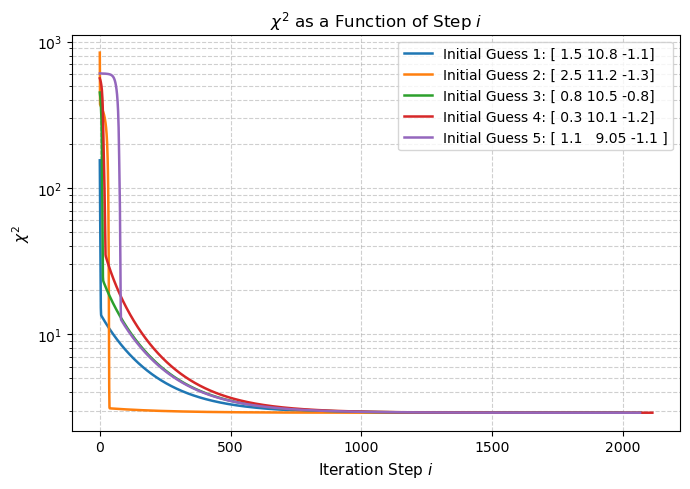

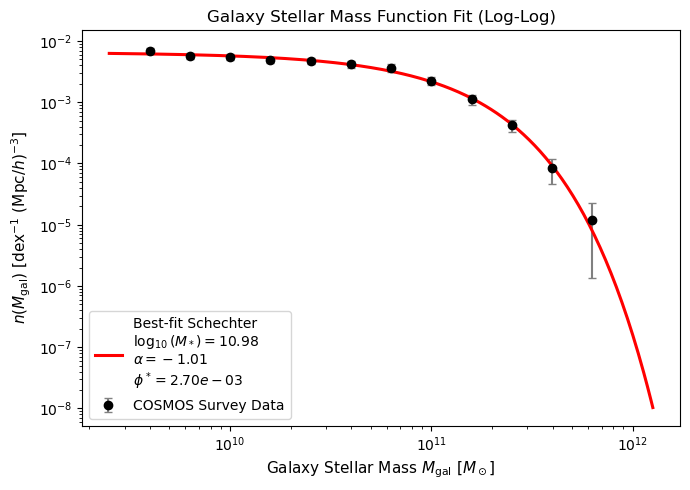

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. データの直接定義 (smf_cosmos.dat)
# ==========================================
raw_data = """
         9.6    0.006871 7.344450e-04
         9.8    0.005688 6.548807e-04
          10    0.005491 5.821939e-04
        10.2    0.004989 5.676684e-04
        10.4     0.00478 5.480215e-04
        10.6     0.00423 5.651628e-04
        10.8    0.003651 4.942570e-04
          11    0.002253 3.711543e-04
        11.2    0.001117 2.077894e-04
        11.4   0.0004182 9.457827e-05
        11.6   8.365e-05 3.661759e-05
        11.8   1.195e-05 1.058371e-05
"""
from io import StringIO
data = np.loadtxt(StringIO(raw_data.strip()))

log_M_data = data[:, 0]  # log10(M_gal)
n_data     = data[:, 1]  # n(M_gal)
err_data   = data[:, 2]  # error
N_points   = len(log_M_data)

# ==========================================
# 2. Schechter関数と目的関数 (LaTeX原稿準拠)
# ==========================================
def schechter(log_M, phi_tilde, log_M_star, alpha):
    phi_star = phi_tilde * 1e-3
    M_star = 10.0**log_M_star
    M = 10.0**log_M
    ratio = M / M_star
    
    # ガード処理
    ratio = np.clip(ratio, 1e-10, 100.0)
    return phi_star * (ratio**(alpha + 1.0)) * np.exp(-ratio) * np.log(10.0)

def chi2_loss(p):
    phi_tilde, log_M_star, alpha = p
    model = schechter(log_M_data, phi_tilde, log_M_star, alpha)
    diff = (n_data - model) / err_data
    val = np.sum(diff**2)
    return val if np.isfinite(val) else 1e12

# ==========================================
# 3. 中心差分による数値微分と最急降下法
# ==========================================
def numerical_gradient(f, p, h=1e-4):
    grad = np.zeros_like(p, dtype=float)
    for j in range(len(p)):
        p_plus = p.copy()
        p_minus = p.copy()
        p_plus[j] += h
        p_minus[j] -= h
        grad[j] = (f(p_plus) - f(p_minus)) / (2.0 * h)
    return grad

def gradient_descent(f, p0, eta=2e-4, max_iter=6000, tol=1e-6):
    p = np.array(p0, dtype=float)
    traj = [p.copy()]
    losses = [f(p)]
    
    current_eta = eta
    for i in range(max_iter):
        grad = numerical_gradient(f, p)
        
        grad_norm = np.linalg.norm(grad)
        if grad_norm > 1e4:
            grad = grad * (1e4 / grad_norm)
            
        p_new = p - current_eta * grad
        loss_new = f(p_new)
        
        n_back = 0
        while loss_new > losses[-1] and n_back < 15:
            current_eta *= 0.5
            p_new = p - current_eta * grad
            loss_new = f(p_new)
            n_back += 1
            
        p = p_new
        traj.append(p.copy())
        losses.append(loss_new)
        
        if abs(losses[-2] - losses[-1]) < tol:
            break
            
    return p, np.array(traj), np.array(losses)

# ==========================================
# 4. 複数初期値での実行 (LaTeX原稿の3点)
# ==========================================
initial_guesses = [
    np.array([1.5, 10.8, -1.1]),  # Guess 1
    np.array([2.5, 11.2, -1.3]),  # Guess 2
    np.array([0.8, 10.5, -0.8]),   # Guess 3
    np.array([0.3, 10.1, -1.2]) ,  # Guess 4
    np.array([1.1, 9.05, -1.1])   # Guess 5
]

results = []
plt.figure(figsize=(7, 5))

for idx, p0 in enumerate(initial_guesses):
    p_opt, traj, losses = gradient_descent(chi2_loss, p0, eta=2e-4, max_iter=6000)
    results.append((p_opt, losses))
    
    plt.plot(losses, lw=1.8, label=f'Initial Guess {idx+1}: {p0}')
    phi_star_val = p_opt[0] * 1e-3
    print(f"Guess {idx+1} Result:")
    print(f"  phi* = {phi_star_val:.3e} (phi_tilde = {p_opt[0]:.3f})")
    print(f"  log10(M*) = {p_opt[1]:.4f}")
    print(f"  alpha = {p_opt[2]:.4f}")
    print(f"  chi2 = {losses[-1]:.3f}, chi2/dof = {losses[-1]/9.0:.3f}\n")

# --- Plot a: chi^2 vs Step i ---
plt.xlabel('Iteration Step $i$', fontsize=11)
plt.ylabel(r'$\chi^2$', fontsize=11)
plt.yscale('log')
plt.title(r'$\chi^2$ as a Function of Step $i$', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('plot_a_chi2_vs_step.png', dpi=300)
plt.show()

# --- Plot b: Best-fit Schechter vs Data ---
best_p = results[0][0]
best_phi_star = best_p[0] * 1e-3
best_log_M_star = best_p[1]
best_alpha = best_p[2]

log_M_fine = np.linspace(log_M_data.min() - 0.2, log_M_data.max() + 0.3, 300)
n_fine = schechter(log_M_fine, best_p[0], best_log_M_star, best_alpha)

plt.figure(figsize=(7, 5))
plt.errorbar(10.0**log_M_data, n_data, yerr=err_data, fmt='o', color='black',
             ecolor='gray', elinewidth=1.5, capsize=3, label='COSMOS Survey Data')

# SyntaxWarning防止のため raw f-string (rf"...") を使用
plt.plot(10.0**log_M_fine, n_fine, 'r-', lw=2.2,
         label=rf'Best-fit Schechter' + '\n' +
               rf'$\log_{{10}}(M_*) = {best_log_M_star:.2f}$' + '\n' +
               rf'$\alpha = {best_alpha:.2f}$' + '\n' +
               rf'$\phi^* = {best_phi_star:.2e}$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Galaxy Stellar Mass $M_{\mathrm{gal}}\ [M_\odot]$', fontsize=11)
plt.ylabel(r'$n(M_{\mathrm{gal}})\ [\mathrm{dex}^{-1}\ (\mathrm{Mpc}/h)^{-3}]$', fontsize=11)
plt.title('Galaxy Stellar Mass Function Fit (Log-Log)', fontsize=12)
plt.legend(frameon=True)

plt.tight_layout()
plt.savefig('plot_b_schechter_fit.png', dpi=300)
plt.show()

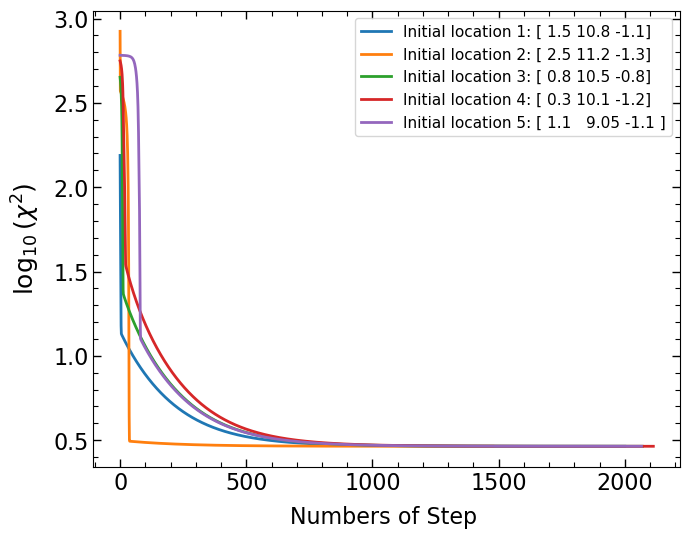

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.figure(figsize=(7, 5.5))
ax = plt.subplot(111)

# マイナー目盛り（補助目盛り）の自動生成を両軸に適用
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# 主目盛り（major）: 内向き、4辺表示、サイズ16
ax.tick_params(direction='in', which='major', length=6, width=1.0, top=True, right=True, labelsize=16)

# マイナー目盛り（minor）: 内向き、4辺表示、やや小さめのサイズ
ax.tick_params(direction='in', which='minor', length=3.5, width=0.8, top=True, right=True)

# 各試行のプロット描画（losses の常用対数をプロット）
for idx, (p_opt, losses) in enumerate(results):
    ax.plot(np.log10(losses), lw=2.0, label=f'Initial location {idx+1}: {initial_guesses[idx]}')

# 軸ラベルの設定（縦軸ラベルを log10(\chi^2) に変更）
ax.set_xlabel('Numbers of Step ', fontsize=16, labelpad=8)
ax.set_ylabel(r'$\log_{10}(\chi^2)$', fontsize=18, labelpad=8)
ax.set_title(r'', fontsize=16, pad=10)

# 凡例（枠線あり、フォントサイズ調整）
ax.legend(frameon=True, fontsize=11, loc='upper right')

# グリッドは非表示
ax.grid(False)

plt.tight_layout()
plt.savefig('plot_a_chi2_vs_step.png', dpi=300)
plt.show()

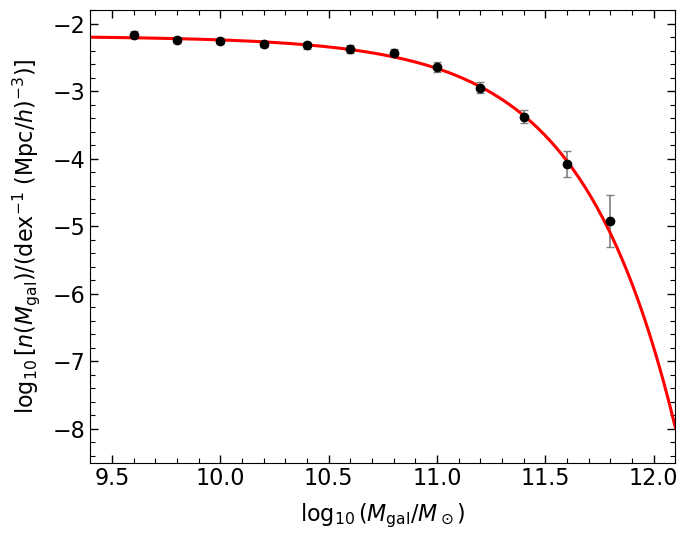

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.figure(figsize=(7, 5.5))
ax = plt.subplot(111)

# マイナー目盛り（補助目盛り）の自動生成
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# 目盛りの設定（先ほどと同一：内向き、4辺表示、主目盛りサイズ16）
ax.tick_params(direction='in', which='major', length=6, width=1.0, top=True, right=True, labelsize=16)
ax.tick_params(direction='in', which='minor', length=3.5, width=0.8, top=True, right=True)

# 1. 観測データの対数変換 (横軸はもともと log10(M_gal))
log_M_obs = log_M_data
log_n_obs = np.log10(n_data)
# 対数空間でのエラーバー: d(log10 y) = (1 / (y * ln 10)) * dy
log_err_obs = err_data / (n_data * np.log(10.0))

# 観測データのプロット（エラーバー付き）
ax.errorbar(log_M_obs, log_n_obs, yerr=log_err_obs, fmt='o', color='black',
            ecolor='gray', elinewidth=1.2, capsize=3, markersize=6, label='Low Data')

# 2. 最良適合Schechter関数の対数変換プロット
log_M_fine = np.linspace(log_M_data.min() - 0.2, 12.1, 300)
# schechter関数から得られるモデル値の常用対数
n_fine = schechter(log_M_fine, best_p[0], best_log_M_star, best_alpha)
log_n_fine = np.log10(n_fine)

ax.plot(log_M_fine, log_n_fine, 'r-', lw=2.2,
        label=rf'Best-fit Schechter' + '\n' +
              rf'$\log_{{10}}(M_*) = {best_log_M_star:.2f}$' + '\n' +
              rf'$\alpha = {best_alpha:.2f}$' + '\n' +
              rf'$\phi^* = {best_phi_star:.2e}$')

# 軸範囲の調整（データと曲線が綺麗に収まる範囲）
ax.set_xlim(9.4, 12.1)
ax.set_ylim(-8.5, -1.8)

# 軸ラベルの設定（サイズを先ほどのグラフと完全統一）
ax.set_xlabel(r'$\log_{10}(M_{\mathrm{gal}} / M_\odot)$', fontsize=16, labelpad=8)
ax.set_ylabel(r'$\log_{10}[n(M_{\mathrm{gal}}) / (\mathrm{dex}^{-1}\ (\mathrm{Mpc}/h)^{-3})]$', fontsize=16, labelpad=8)
ax.set_title(r'', fontsize=16, pad=10)

# 凡例・グリッド
#ax.legend(frameon=True, fontsize=11, loc='lower left')
#ax.grid(False)

plt.tight_layout()
plt.savefig('plot_b_schechter_fit.png', dpi=300)
plt.show()